In [36]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc
)


# Optional: clean plotting style
sns.set(style="whitegrid")

In [37]:
# Cell 2: Load Data
df = pd.read_csv(r"D:/Heart Disease/heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [38]:
# Cell 3: Basic Info
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df["target"].value_counts())

Shape: (1025, 14)

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target Distribution:
 target
1    526
0    499
Name: count, dtype: int64


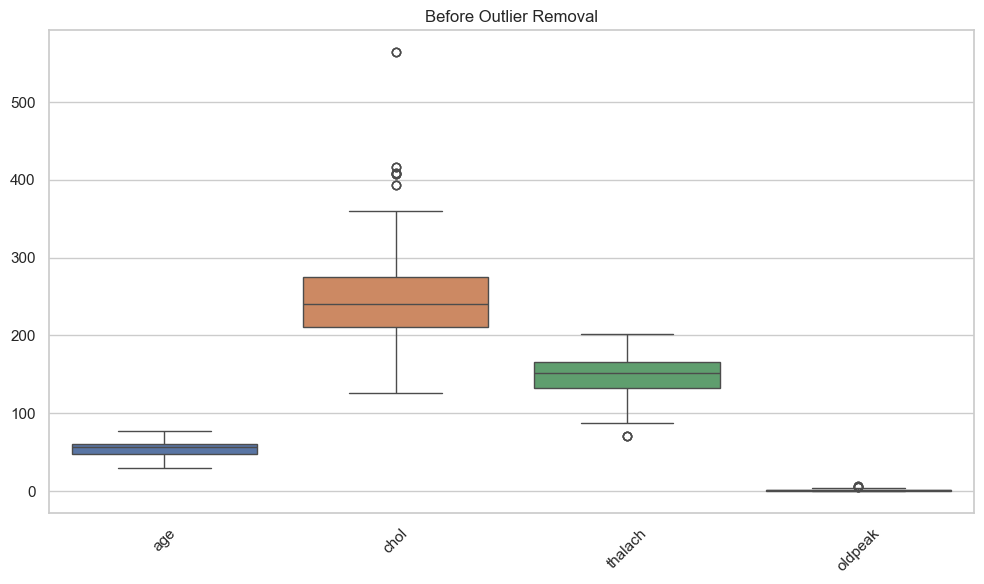

In [39]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df[["age", "chol", "thalach", "oldpeak"]])

plt.title("Before Outlier Removal")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_clean = df_clean[
            (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)
        ]
    
    return df_clean

columns_to_clean = ["age", "chol", "thalach", "oldpeak"]

df_cleaned = remove_outliers_iqr(df, columns_to_clean)

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_cleaned.shape)

Original Shape: (1025, 14)
After Removing Outliers: (998, 14)


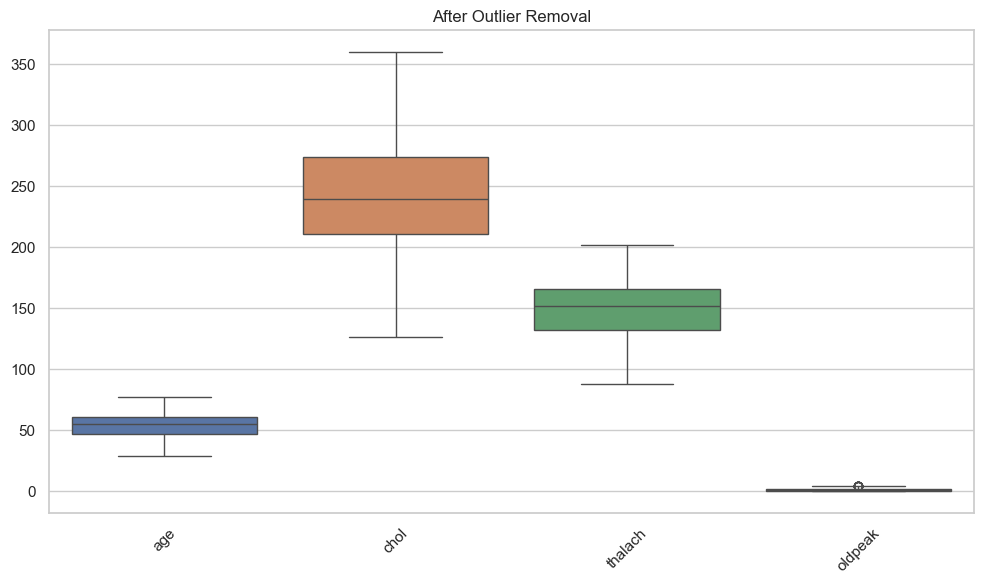

In [41]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_cleaned[["age", "chol", "thalach", "oldpeak"]])

plt.title("After Outlier Removal")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
df = df_cleaned.copy()

In [43]:
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 55, 70, 100], labels=[0,1,2,3]).astype(int)

df['chol_level'] = pd.cut(df['chol'], bins=[0, 200, 240, 600], labels=[0,1,2]).astype(int)

df['thalach_level'] = pd.cut(df['thalach'], bins=[0, 100, 150, 220], labels=[0,1,2]).astype(int)

df['age_chol_interaction'] = df['age'] * df['chol']

df['oldpeak_log'] = np.log1p(df['oldpeak'])

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_level,thalach_level,age_chol_interaction,oldpeak_log
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,1,1,2,11024,0.693147
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,1,1,2,10759,1.410987
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,2,0,1,12180,1.280934
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,2,1,2,12383,0.000000
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,2,2,1,18228,1.064711


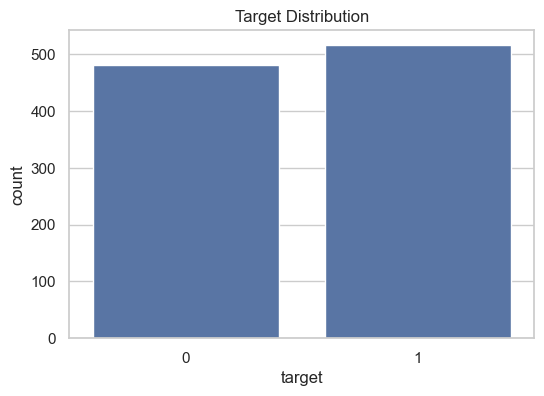

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.show()

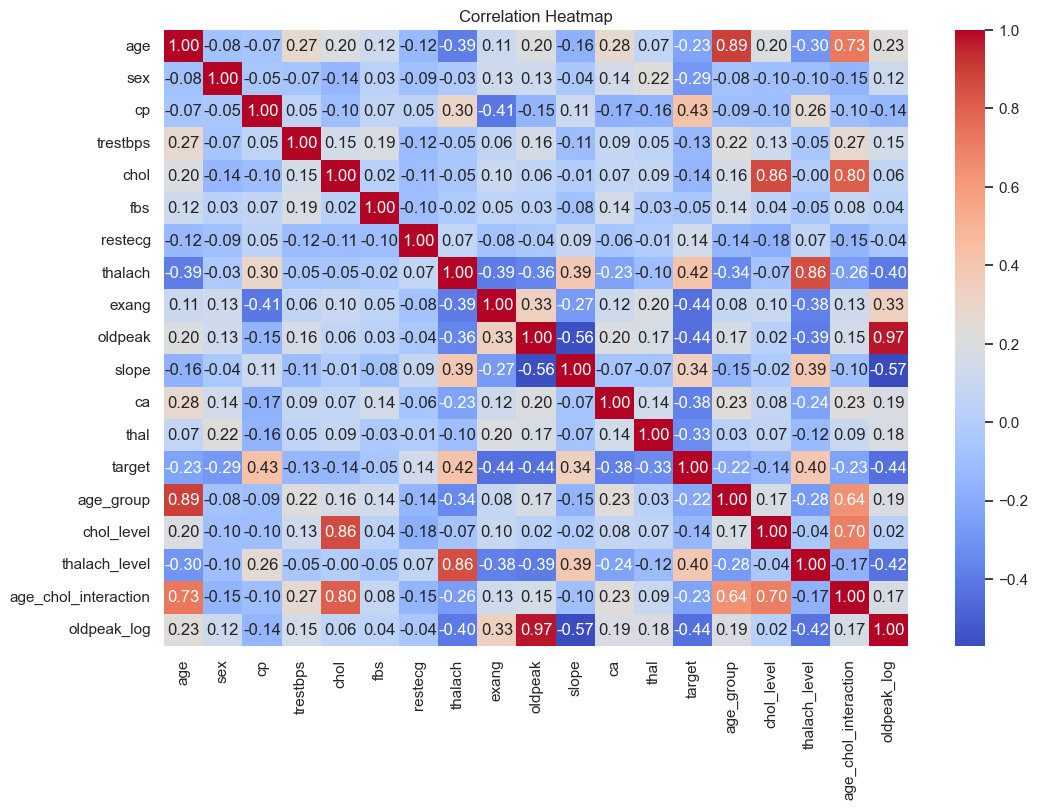

In [45]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

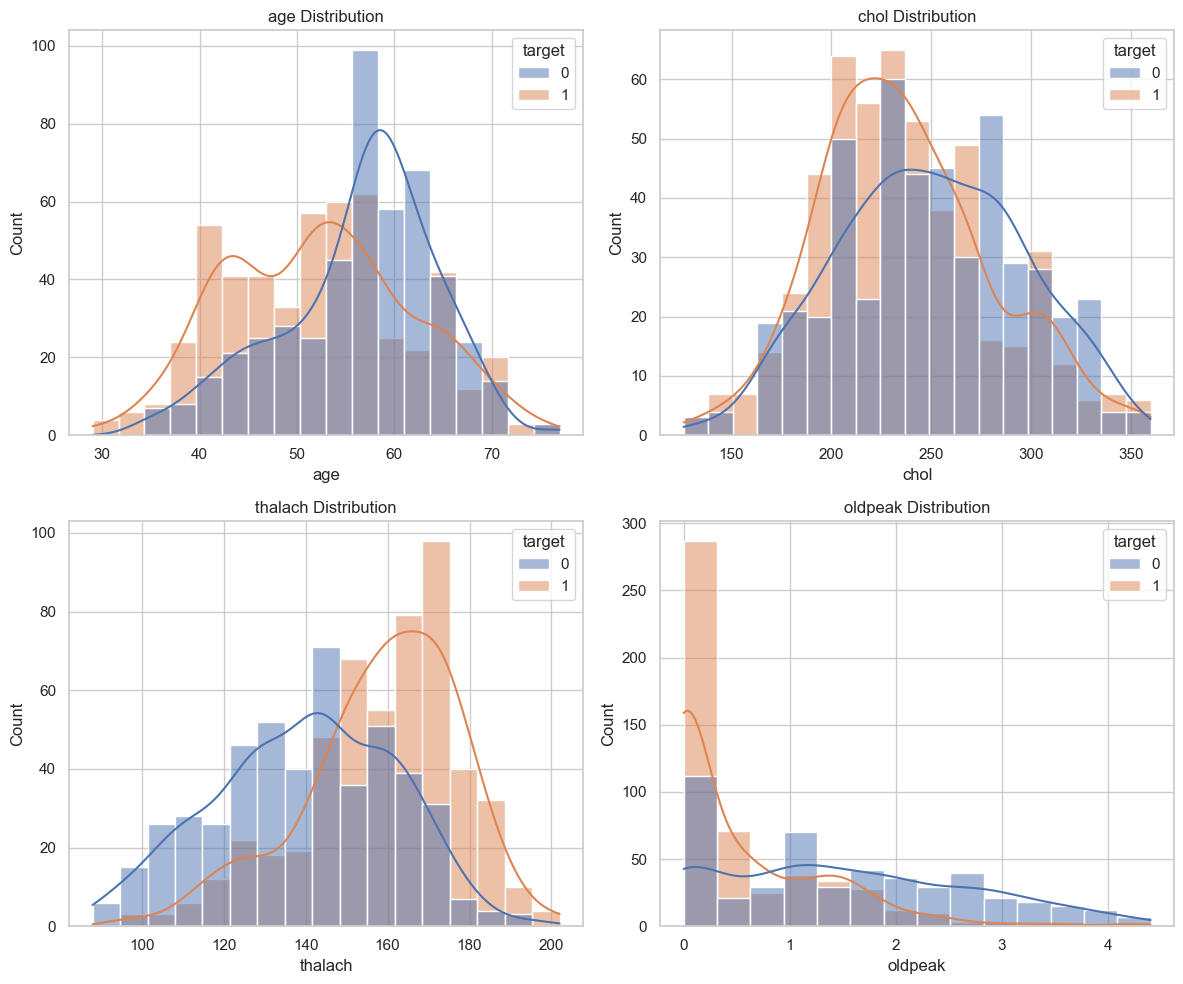

In [46]:
features = ["age", "chol", "thalach", "oldpeak"]

plt.figure(figsize=(12,10))

for i, feature in enumerate(features, 1):
    plt.subplot(2,2,i)
    sns.histplot(data=df, x=feature, hue="target", kde=True)
    plt.title(f"{feature} Distribution")

plt.tight_layout()
plt.show()

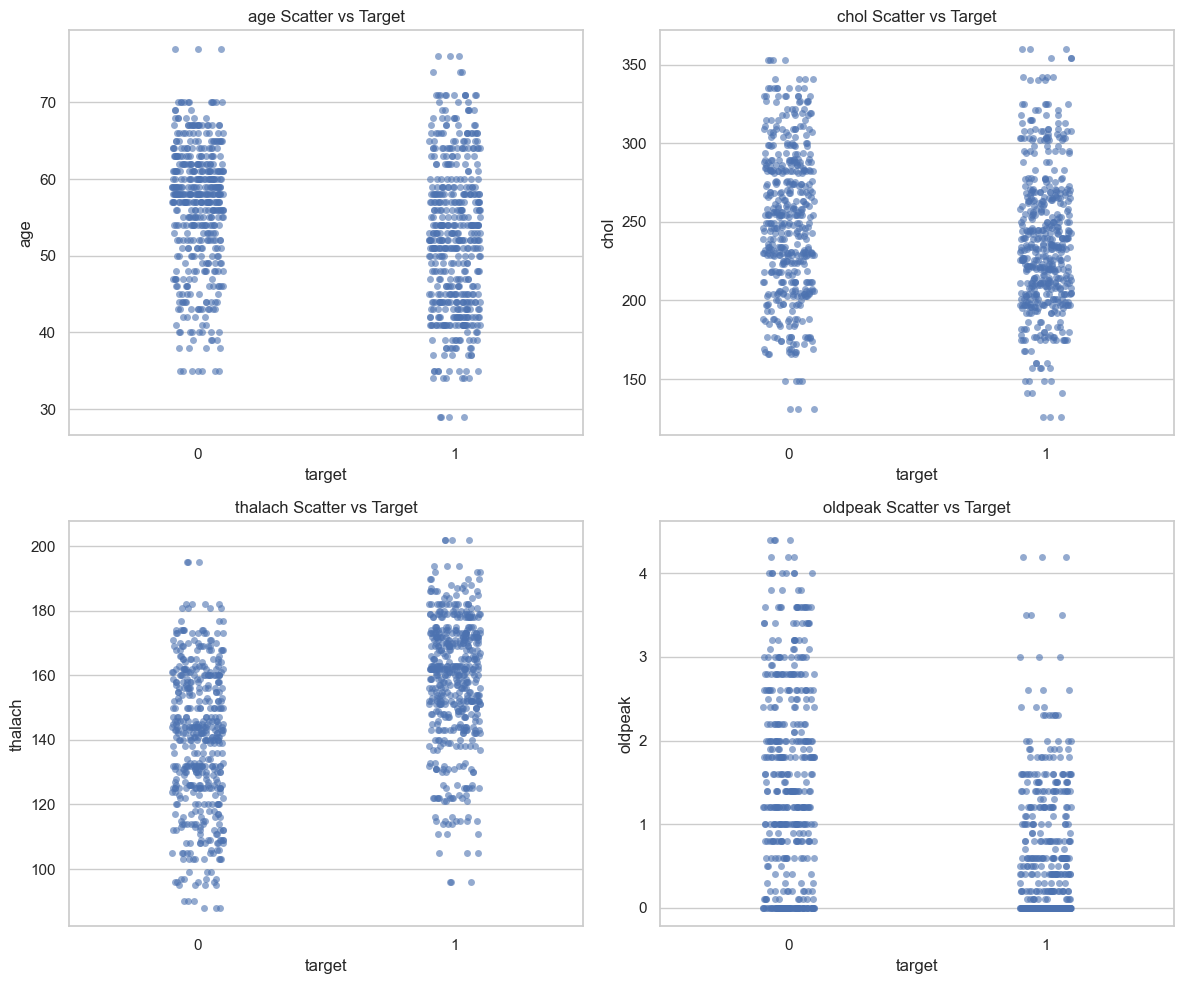

In [47]:
# Strip Plot

features = ["age", "chol", "thalach", "oldpeak"]

plt.figure(figsize=(12,10))

for i, feature in enumerate(features, 1):
    plt.subplot(2,2,i)
    
    sns.stripplot(
        x="target",
        y=feature,
        data=df,
        jitter=True,
        alpha=0.6
    )
    
    plt.title(f"{feature} Scatter vs Target")

plt.tight_layout()
plt.show()

In [48]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
numeric_features = [
    "age", "chol", "thalach", "oldpeak",
    "age_chol_interaction", "oldpeak_log"
]

scaler = ColumnTransformer([
    ("num", StandardScaler(), numeric_features)
], remainder="passthrough")

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB()
   
}


Logistic Regression Accuracy: 0.8350
              precision    recall  f1-score   support

           0       0.90      0.72      0.80        92
           1       0.80      0.94      0.86       108

    accuracy                           0.83       200
   macro avg       0.85      0.83      0.83       200
weighted avg       0.85      0.83      0.83       200



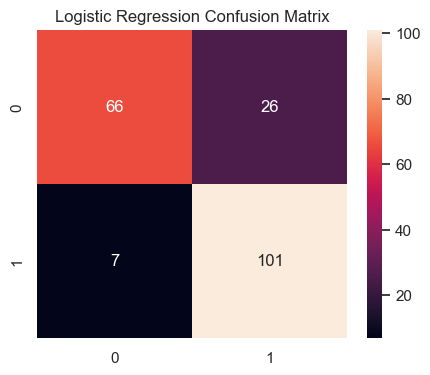


Naive Bayes Accuracy: 0.7950
              precision    recall  f1-score   support

           0       0.82      0.71      0.76        92
           1       0.78      0.87      0.82       108

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.80      0.79       200



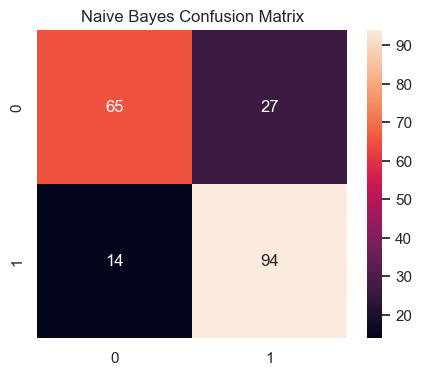

In [51]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

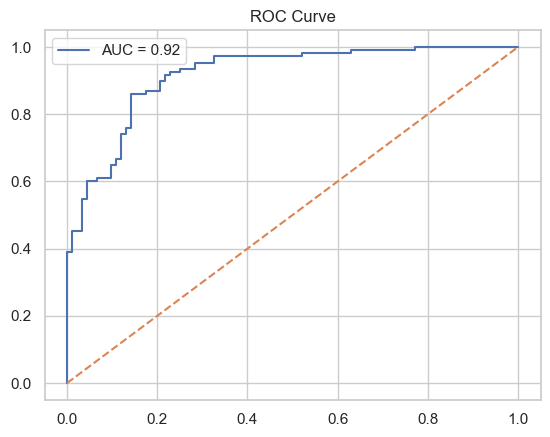

In [52]:
lr_model = models["Logistic Regression"]

y_prob = lr_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [53]:
comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
}).sort_values(by="Accuracy", ascending=False)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.835
1,Naive Bayes,0.795


In [54]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

joblib.dump(best_model, "heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Best Model: Logistic Regression
Model and scaler saved successfully!
